In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("Students.csv")

In [8]:
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,110.0,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,NaN,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3
...,...,...,...,...,...,...
98,69,88.0,55.0,99.0,NaN,3
99,67,84.0,62.0,81.0,NaN,2
100,67,87.0,54.0,80.0,2021.0,2
101,46,56.0,87.0,67.0,2022.0,1


In [9]:
df.head()

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,110.0,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,NaN,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3


In [10]:
df.shape

(103, 6)

In [11]:
df.columns

Index(['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score',
       'Club_Join_Date', 'Placement_Offer_Count'],
      dtype='object')

In [12]:
df.isnull().sum()

Math_Score                0
Reading_Score             7
Writing_Score             7
Placement_Score           3
Club_Join_Date           23
Placement_Offer_Count     0
dtype: int64

In [13]:
df.dtypes

Math_Score                 int64
Reading_Score            float64
Writing_Score            float64
Placement_Score          float64
Club_Join_Date           float64
Placement_Offer_Count      int64
dtype: object

In [14]:
series = pd.isnull(df["Math_Score"])
df[series]

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count


In [15]:
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Reading_Score'] = df['Reading_Score'].fillna(df['Reading_Score'].median())
df['Writing_Score'] = df['Writing_Score'].fillna(df['Writing_Score'].median())
df['Placement_Score'] = df['Placement_Score'].fillna(df['Placement_Score'].mean())
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,110.0,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,NaN,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3
...,...,...,...,...,...,...
98,69,88.0,55.0,99.0,NaN,3
99,67,84.0,62.0,81.0,NaN,2
100,67,87.0,54.0,80.0,2021.0,2
101,46,56.0,87.0,67.0,2022.0,1


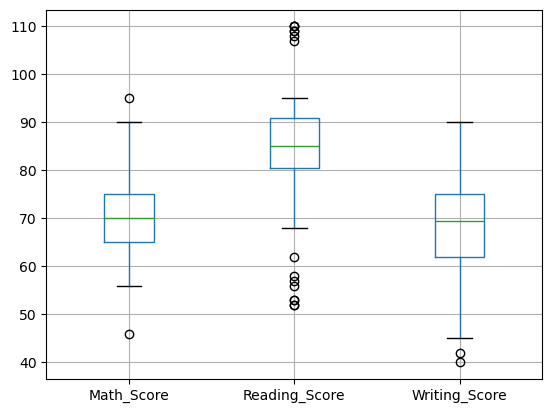

In [17]:
col = ['Math_Score', 'Reading_Score', 'Writing_Score']
df.boxplot(col)
plt.show()

In [18]:
df['Club_Join_Date'] = df['Club_Join_Date'].fillna(df['Club_Join_Date'].mode()[0])

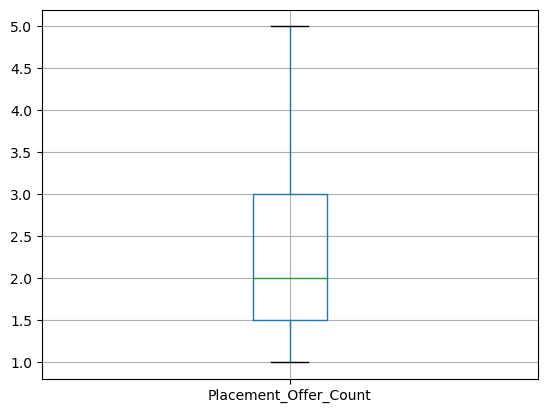

In [20]:
col = ['Placement_Offer_Count']
df.boxplot(col)
plt.show()

In [21]:
import numpy as np
from scipy import stats
z = np.abs(stats.zscore(df['Math_Score']))
print(z)

[0.79972991 0.25058204 0.29856583 0.98500068 1.39686158 0.84771371
 0.29856583 0.93701688 0.66244295 0.25058204 0.29856583 0.11329507
 0.93701688 0.98500068 0.84771371 1.21159082 1.34887779 0.4358528
 0.98500068 0.71042674 0.98500068 0.52515598 1.89802566 0.52515598
 1.34887779 0.79972991 0.52515598 1.62345173 1.25957462 0.29856583
 0.16127887 1.21159082 1.25957462 0.4358528  0.84771371 1.12228765
 0.0239919  0.29856583 1.39686158 0.66244295 0.84771371 1.39686158
 0.66244295 1.07430385 0.4358528  0.16127887 0.11329507 1.07430385
 0.4358528  1.25957462 0.0239919  1.39686158 0.29856583 0.16127887
 0.66244295 1.07430385 0.25058204 0.25058204 0.38786901 0.4358528
 0.71042674 1.21159082 1.34887779 0.0239919  0.71042674 1.12228765
 1.25957462 1.07430385 0.16127887 0.98500068 0.38786901 0.79972991
 0.38786901 0.0239919  0.93701688 0.52515598 1.39686158 0.93701688
 0.29856583 0.84771371 1.25957462 0.71042674 0.0239919  1.34887779
 0.66244295 1.21159082 0.0239919  0.4358528  1.07430385 2.769731

In [22]:
np.where

<function where at 0x0000027DD15BDE30>

In [23]:
threshold = 3
np.where(z > threshold)

(array([ 97, 101]),)

In [24]:
sorted_rscore = sorted(df['Reading_Score'])
q1 = np.percentile(sorted_rscore, 25)
q3 = np.percentile(sorted_rscore, 75)
IQR = q3 - q1
lower = q1 - (1.5 * IQR)
upper = q3 + (1.5 * IQR)

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: 64.75
Upper Bound: 106.75


In [25]:
outliers = []
for i in sorted_rscore:
    if i < lower or i > upper:
        outliers.append(i)
outliers

[52.0,
 52.0,
 53.0,
 53.0,
 56.0,
 57.0,
 58.0,
 62.0,
 107.0,
 108.0,
 109.0,
 109.0,
 110.0,
 110.0,
 110.0]

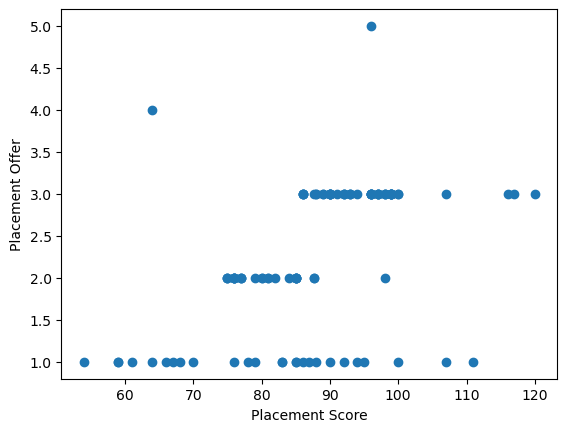

In [26]:
plt.scatter(df['Placement_Score'], df['Placement_Offer_Count'])
plt.xlabel("Placement Score")
plt.ylabel("Placement Offer")

plt.show()

In [28]:
print(np.where((df['Placement_Score'] > 85) & (df['Placement_Offer_Count'] < 3)))

(array([  9,  15,  27,  36,  45,  61,  66,  83,  85,  87,  92,  96, 102]),)


In [30]:
Q1 = df['Reading_Score'].quantile(0.25)
Q3 = df['Reading_Score'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

Q1: 80.5
Q3: 91.0
IQR: 10.5
Lower Bound: 64.75
Upper Bound: 106.75


In [31]:
median = np.median(sorted_rscore)
df['Reading_Score'] = np.where(df['Reading_Score'] > upper,median,df['Reading_Score'])
df['Reading_Score'] = np.where(df['Reading_Score'] < lower,median,df['Reading_Score'])
df

,Math_Score,Reading_Score,Writing_Score,Placement_Score,Club_Join_Date,Placement_Offer_Count
0,64,85.0,70.0,88.0,2020.0,3
1,68,94.0,62.0,79.0,2020.0,2
2,72,88.0,77.0,90.0,2018.0,3
3,77,80.0,63.0,99.0,2020.0,3
4,80,93.0,60.0,96.0,2020.0,3
...,...,...,...,...,...,...
98,69,88.0,55.0,99.0,2020.0,3
99,67,84.0,62.0,81.0,2020.0,2
100,67,87.0,54.0,80.0,2021.0,2
101,46,85.0,87.0,67.0,2022.0,1


In [35]:
df.loc[df['Placement_Score'] < 75, 'Placement_Offer'] = 1
df.loc[(df['Placement_Score'] >= 75) & (df['Placement_Score'] <= 85),'Placement_Offer'] = 2
df.loc[df['Placement_Score'] > 85, 'Placement_Offer'] = 3
print(df.head())

   Math_Score  Reading_Score  Writing_Score  Placement_Score  Club_Join_Date  \
0          64           85.0           70.0             88.0          2020.0   
1          68           94.0           62.0             79.0          2020.0   
2          72           88.0           77.0             90.0          2018.0   
3          77           80.0           63.0             99.0          2020.0   
4          80           93.0           60.0             96.0          2020.0   

   Placement_Offer_Count  Placement_Offer  
0                      3              3.0  
1                      2              2.0  
2                      3              3.0  
3                      3              3.0  
4                      3              3.0  


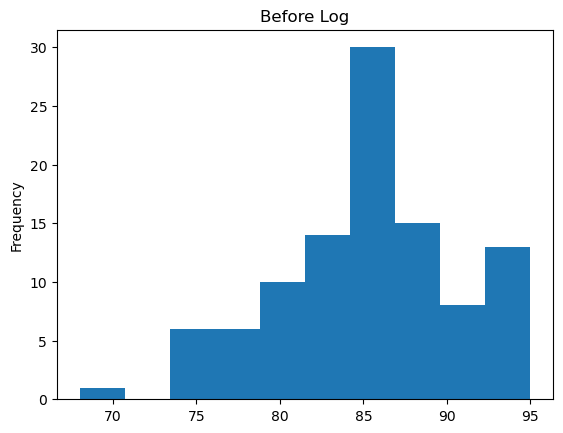

In [36]:
df['Reading_Score'].plot(kind='hist')
plt.title("Before Log")
plt.show()

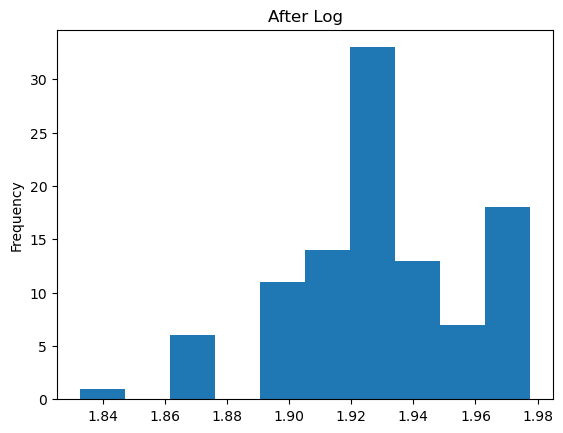

In [37]:
df['log_reading'] = np.log10(df['Reading_Score'])

df['log_reading'].plot(kind='hist')
plt.title("After Log")
plt.show()